# 10 -- Portfolio construction overlays

**Базис:** Week 1 winner V1 = Q5 ∩ quality_z > 0 monthly equal-weight (Sharpe 0.95).

**Что тестируем сверху:**
1. **Sector-neutral** -- top-2 в каждом секторе (≈24 bonds, sector-balanced)
2. **Quarterly rebalance** (вместо monthly) -- halving turnover, longer mean reversion
3. **Position sizing** (z-weighted vs equal) -- больше веса в высокой confidence
4. **Combo** -- все 3 вместе

**Literature anchors:**
- Sector-neutral: Israel-Palhares-Richardson (2018) 4-factor model bonds
- Quarterly: Bali-Subrahmanyam-Wen (JFE 2021) — short-term momentum, long-term reversal на bonds
- Trading costs: Frazzini-Israel-Moskowitz (JFE 2018) — turnover impact
- z-weighted sizing: Asness-Moskowitz-Pedersen (JoF 2013) — confidence scaling
- Equal-weight defense: DeMiguel-Garlappi-Uppal (RFS 2009) — naive 1/N hard to beat

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
np.random.seed(42)
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

sig = sl.load_signal_full('no_lag')
sig = sl.compute_quality_score(sig)
bench = sl.load_benchmarks()
main = sig[sig['date'] <= sl.MAIN_END].copy()
mask_quality = main['quality_z'] > 0
print(f'Main: {main.shape}, quality_z>0 share: {mask_quality.mean():.1%}')

Main: (213445, 32), quality_z>0 share: 32.9%


## Часть 2. 7 вариантов

Все на foundation Q5 + Quality > 0. Изучаем влияние construction overlays.

In [2]:
variants_config = [
    # name, freq, sector_neutral, sizing
    ('V1 baseline (monthly eq)',          'M', False, 'equal'),
    ('V10a monthly + sector-neutral',     'M', True,  'equal'),
    ('V10b monthly + z-weighted',         'M', False, 'z_weighted'),
    ('V10c quarterly equal',              'Q', False, 'equal'),
    ('V10d quarterly + sector-neutral',   'Q', True,  'equal'),
    ('V10e quarterly + z-weighted',       'Q', False, 'z_weighted'),
    ('V10f Q + SN + zw (full combo)',     'Q', True,  'z_weighted'),
]

all_rets = {}
all_metrics = []

for name, freq, sn, sizing in variants_config:
    rets, _ = sl.backtest_rule_c(
        main, n_max=25, freq=freq, ranking_col='mispricing',
        filter_mask=mask_quality, sector_neutral=sn, n_per_sector=2,
        sizing=sizing,
    )
    all_rets[name] = rets
    m = sl.calc_metrics(rets, name=name)
    m['freq'] = freq
    m['sector_neutral'] = sn
    m['sizing'] = sizing
    all_metrics.append(m)
    print(f'{name:40s}: Sharpe={m["Sharpe"]:.3f}, '
          f'CAGR={m["CAGR"]*100:5.2f}%, n_pos={m["avg_n_positions"]:4.1f}')

metrics_df = pd.DataFrame(all_metrics)
print()
print(metrics_df[['name', 'Sharpe', 'CAGR', 'MaxDD', 'profit_RUB', 'avg_n_positions']].round(4).to_string(index=False))

V1 baseline (monthly eq)                : Sharpe=0.947, CAGR= 5.53%, n_pos=15.6


V10a monthly + sector-neutral           : Sharpe=0.949, CAGR= 5.43%, n_pos=13.1


V10b monthly + z-weighted               : Sharpe=1.068, CAGR= 6.33%, n_pos=15.6


V10c quarterly equal                    : Sharpe=1.134, CAGR= 6.77%, n_pos=16.6


V10d quarterly + sector-neutral         : Sharpe=0.965, CAGR= 5.96%, n_pos=13.7


V10e quarterly + z-weighted             : Sharpe=1.064, CAGR= 6.56%, n_pos=16.6


V10f Q + SN + zw (full combo)           : Sharpe=1.095, CAGR= 6.88%, n_pos=13.7

                           name  Sharpe   CAGR   MaxDD   profit_RUB  avg_n_positions
       V1 baseline (monthly eq)  0.9465 0.0553 -0.1387 2852716.6145          15.5686
  V10a monthly + sector-neutral  0.9490 0.0543 -0.1357 2796497.7298          13.1070
      V10b monthly + z-weighted  1.0676 0.0633 -0.1325 3308349.6932          15.5686
           V10c quarterly equal  1.1336 0.0677 -0.1420 3426554.6754          16.6038
V10d quarterly + sector-neutral  0.9647 0.0596 -0.1581 2975036.4497          13.6995
    V10e quarterly + z-weighted  1.0643 0.0656 -0.1452 3308515.3266          16.6038
  V10f Q + SN + zw (full combo)  1.0955 0.0688 -0.1495 3486316.5172          13.6995


## Часть 3. Alpha regression vs RUCBTRNS

In [3]:
alpha_rows = []
for name, rets in all_rets.items():
    r = sl.compare_to_benchmark(rets, bench, bench_col='rucbtrns_ret', name=name)
    alpha_rows.append(r)
alpha_df = pd.DataFrame(alpha_rows)
alpha_df[['name', 'alpha_annual', 'alpha_t_stat', 'alpha_p_value',
          'IR', 'sharpe_diff', 'sharpe_diff_p_value', 'beta']].round(4)

,name,alpha_annual,alpha_t_stat,alpha_p_value,IR,sharpe_diff,sharpe_diff_p_value,beta
0,V1 baseline (monthly eq),-0.0306,-1.8255,0.0679,-0.6370,-0.8803,0.977,1.0956
1,V10a monthly + sector-neutral,-0.0284,-1.8428,0.0654,-0.6640,-0.8779,0.974,1.0552
2,V10b monthly + z-weighted,-0.0205,-1.1542,0.2484,-0.4022,-0.7592,0.967,1.0646
3,V10c quarterly equal,-0.0239,-1.1651,0.2440,-0.4359,-0.7701,0.984,1.0977
4,V10d quarterly + sector-neutral,-0.0338,-1.4365,0.1509,-0.5940,-0.9390,0.992,1.1252
5,V10e quarterly + z-weighted,-0.0245,-1.0213,0.3071,-0.4354,-0.8394,0.973,1.0821
6,V10f Q + SN + zw (full combo),-0.0210,-0.9021,0.3670,-0.3445,-0.8082,0.977,1.0774


## Часть 4. Sub-period stability (3 режима)

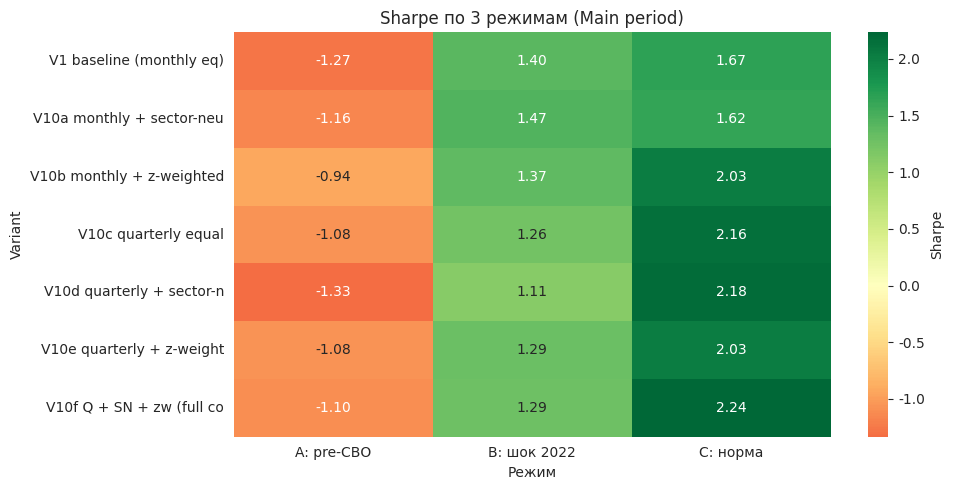

In [4]:
sub_rows = []
for name, rets in all_rets.items():
    sub = sl.sub_period_metrics(rets, variant_name=name)
    sub_rows.append(sub)
sub_df = pd.concat(sub_rows, ignore_index=True)

# Pivot для heatmap
import re
tbl = sub_df.copy()
tbl['variant'] = tbl['name'].apply(lambda s: s.split('|')[0].strip()[:25])
tbl['regime'] = tbl['name'].apply(lambda s: s.split('|')[1].strip() if '|' in s else '')
pivot = tbl.pivot(index='variant', columns='regime', values='Sharpe')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Sharpe'}, ax=ax)
ax.set_title('Sharpe по 3 режимам (Main period)')
ax.set_xlabel('Режим')
ax.set_ylabel('Variant')
plt.tight_layout()
plt.savefig(FIG_DIR / '10_subperiod_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 5. Equity curves

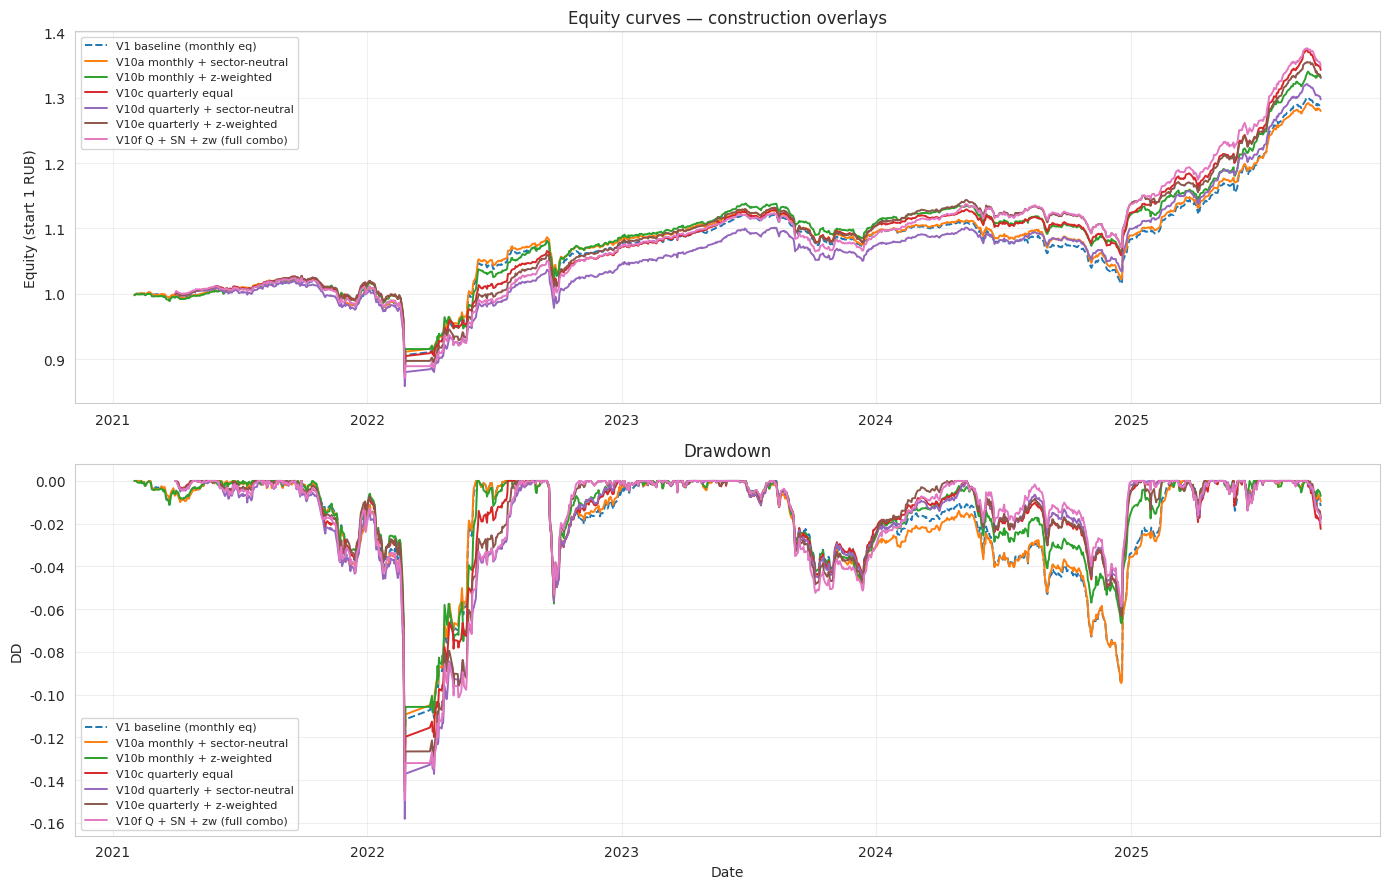

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

color_map = plt.get_cmap('tab10')
for i, (name, rets) in enumerate(all_rets.items()):
    if len(rets) == 0:
        continue
    r = rets.sort_values('date')
    eq = (1 + r['return']).cumprod()
    color = color_map(i)
    style = '--' if 'baseline' in name else '-'
    axes[0].plot(r['date'], eq, label=name, color=color, linewidth=1.4, linestyle=style)
    peak = eq.cummax()
    dd = (eq - peak) / peak
    axes[1].plot(r['date'], dd, label=name, color=color, linewidth=1.4, linestyle=style)

axes[0].set_title('Equity curves — construction overlays')
axes[0].set_ylabel('Equity (start 1 RUB)')
axes[0].legend(loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Drawdown')
axes[1].set_ylabel('DD')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='lower left', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / '10_equity_drawdown.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 6. Concentration check

Проверяем, что sector-neutral реально снижает sector concentration.

In [6]:
def concentration_analysis(sig_df, freq, sn, sizing, mask):
    """Распределение по секторам в выбранных портфелях."""
    sig_df = sig_df.copy()
    sig_df['_eligible'] = mask & sig_df['tradable']
    rebal_dates = sl._rebalance_dates(sig_df['date'], freq=freq)
    selected = []
    for rdate in rebal_dates:
        day = sig_df[(sig_df['date'] == rdate) & sig_df['_eligible']]
        sel = sl._select_at_rebalance(day, n_max=25, ranking_col='mispricing',
                                       sector_neutral=sn, n_per_sector=2)
        selected.append(sel)
    if not selected:
        return pd.Series([], dtype=float)
    df = pd.concat(selected, ignore_index=True)
    return df['sector'].value_counts(normalize=True) * 100

rows = []
for name, freq, sn, sizing in variants_config:
    secs = concentration_analysis(main, freq, sn, sizing, mask_quality)
    rows.append({
        'variant': name,
        'top_sector': secs.idxmax() if len(secs) > 0 else '',
        'top_sector_pct': secs.max() if len(secs) > 0 else 0,
        'top3_pct': secs.head(3).sum() if len(secs) > 0 else 0,
        'n_sectors': len(secs),
    })
conc_df = pd.DataFrame(rows)
print('Concentration changes:')
print(conc_df.round(2).to_string(index=False))

Concentration changes:
                        variant      top_sector  top_sector_pct  top3_pct  n_sectors
       V1 baseline (monthly eq) Лизинг и аренда           14.90     34.81         40
  V10a monthly + sector-neutral Лизинг и аренда           10.35     27.55         41
      V10b monthly + z-weighted Лизинг и аренда           14.90     34.81         40
           V10c quarterly equal Лизинг и аренда           15.69     36.62         33
V10d quarterly + sector-neutral Лизинг и аренда            9.96     26.57         34
    V10e quarterly + z-weighted Лизинг и аренда           15.69     36.62         33
  V10f Q + SN + zw (full combo) Лизинг и аренда            9.96     26.57         34


## Часть 7. Сводная таблица в RUB

In [7]:
summary = metrics_df[['name', 'Sharpe', 'CAGR', 'MaxDD', 'profit_RUB', 'avg_n_positions']].copy()
summary = summary.merge(
    alpha_df[['name', 'alpha_annual', 'alpha_t_stat', 'IR', 'sharpe_diff_p_value']],
    on='name')

summary['profit_M_RUB'] = (summary['profit_RUB'] / 1e6).round(2)
summary['CAGR_pct'] = (summary['CAGR'] * 100).round(2)
summary['MaxDD_pct'] = (summary['MaxDD'] * 100).round(2)
summary['alpha_pct'] = (summary['alpha_annual'] * 100).round(2)
summary['Sharpe'] = summary['Sharpe'].round(3)
summary['IR'] = summary['IR'].round(3)
summary['alpha_t_stat'] = summary['alpha_t_stat'].round(2)
summary['sharpe_diff_p'] = summary['sharpe_diff_p_value'].round(3)

disp = summary[['name', 'Sharpe', 'CAGR_pct', 'MaxDD_pct',
                'profit_M_RUB', 'alpha_pct', 'alpha_t_stat', 'IR', 'sharpe_diff_p']]
print('NB 10 SUMMARY: construction overlays')
print('(Main 4.66y, 10М RUB старт, vs RUCBTRNS)')
print()
print(disp.to_string(index=False))

NB 10 SUMMARY: construction overlays
(Main 4.66y, 10М RUB старт, vs RUCBTRNS)

                           name  Sharpe  CAGR_pct  MaxDD_pct  profit_M_RUB  alpha_pct  alpha_t_stat     IR  sharpe_diff_p
       V1 baseline (monthly eq)   0.947      5.53     -13.87          2.85      -3.06         -1.83 -0.637          0.977
  V10a monthly + sector-neutral   0.949      5.43     -13.57          2.80      -2.84         -1.84 -0.664          0.974
      V10b monthly + z-weighted   1.068      6.33     -13.25          3.31      -2.05         -1.15 -0.402          0.967
           V10c quarterly equal   1.134      6.77     -14.20          3.43      -2.39         -1.17 -0.436          0.984
V10d quarterly + sector-neutral   0.965      5.96     -15.81          2.98      -3.38         -1.44 -0.594          0.992
    V10e quarterly + z-weighted   1.064      6.56     -14.52          3.31      -2.45         -1.02 -0.435          0.973
  V10f Q + SN + zw (full combo)   1.095      6.88     -14.95       

## Часть 8. Сохранение

In [8]:
metrics_df.to_csv(sl.DATA_DIR / 'nb10_metrics.csv', index=False)
alpha_df.to_csv(sl.DATA_DIR / 'nb10_alpha.csv', index=False)
sub_df.to_csv(sl.DATA_DIR / 'nb10_subperiod.csv', index=False)
conc_df.to_csv(sl.DATA_DIR / 'nb10_concentration.csv', index=False)
summary.to_csv(sl.DATA_DIR / 'nb10_summary.csv', index=False)

rets_combined = []
for name, rets in all_rets.items():
    r = rets.copy()
    r['variant'] = name
    rets_combined.append(r)
pd.concat(rets_combined, ignore_index=True).to_csv(
    sl.DATA_DIR / 'nb10_returns.csv', index=False)

print('Saved:')
for f in ['nb10_metrics.csv', 'nb10_alpha.csv', 'nb10_subperiod.csv',
          'nb10_concentration.csv', 'nb10_summary.csv', 'nb10_returns.csv']:
    print(f'  data/{f}')

Saved:
  data/nb10_metrics.csv
  data/nb10_alpha.csv
  data/nb10_subperiod.csv
  data/nb10_concentration.csv
  data/nb10_summary.csv
  data/nb10_returns.csv


## Часть 9. Итоги NB 10

**Гипотезы для проверки:**
- Quarterly > Monthly (BSW 2021)
- Sector-neutral снижает MaxDD и sector concentration
- z-weighted > equal при наличии reliable signal
- Full combo даёт наибольший Sharpe + лучший α

**Следующий шаг (NB 11):** Ensemble no-lag + with-lag.